<a href="https://colab.research.google.com/github/Bonesha-5/PCA_Formative_Peer_Pair_3/blob/main/PCA_Formative_1%5BPeer_Pair_3%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

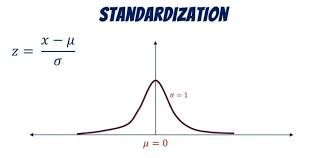


Import libraries

In [ ]:
#Importing libraries
import numpy as np
import matplotlib.pyplot as plt

Load and clean the CSV structure

In [ ]:
file_path = 'africa_education_2015_2019.csv'

# Read all lines from the CSV file
with open(file_path, 'r', encoding='utf-8') as file:
    lines = file.readlines()

# Separate the header from the data
header_line = lines[0].strip()

data_lines = []

for line in lines[1:]:
    line = line.strip()

    # Ignore empty rows and database information at the bottom
    if line == "":
        continue

    if line.startswith("Data from database"):
        continue

    if line.startswith("Last Updated"):
        continue

    data_lines.append(line)


# Function to correctly separate CSV values,
# including values that contain commas inside quotation marks
def parse_csv_line(line):
    fields = []
    current = ""
    inside_quotes = False

    for character in line:
        if character == '"':
            inside_quotes = not inside_quotes

        elif character == ',' and not inside_quotes:
            fields.append(current)
            current = ""

        else:
            current += character

    fields.append(current)

    return fields


# Parse the header and data
header = np.array(parse_csv_line(header_line), dtype=str)

data = np.array(
    [parse_csv_line(line) for line in data_lines],
    dtype=str
)

print("Data shape:", data.shape)
print("Number of columns:", len(header))
print("First row:")
print(data[0])

Data shape: (273, 15)
Number of columns: 15
First row:
['2015' 'YR2015' 'Algeria' 'DZA' '..' '..' '109.584787441309' '..'
 '38.2444735695552' '98.4612319244171' '0.410926282137215' '23.83613'
 '100' '6.17633014564047' '0.952300012111664']


Display column names

In [ ]:
print("Column names:")

for i in range(len(header)):
    print(i, ":", header[i])

Column names:
0 : Time
1 : Time Code
2 : Country Name
3 : Country Code
4 : Literacy rate, adult total (% of people ages 15 and above) [SE.ADT.LITR.ZS]
5 : Literacy rate, youth total (% of people ages 15-24) [SE.ADT.1524.LT.ZS]
6 : School enrollment, primary (% gross) [SE.PRM.ENRR]
7 : School enrollment, secondary (% gross) [SE.SEC.ENRR]
8 : School enrollment, tertiary (% gross) [SE.TER.ENRR]
9 : Primary completion rate, total (% of relevant age group) [SE.PRM.CMPT.ZS]
10 : Children out of school (% of primary school age) [SE.PRM.UNER.ZS]
11 : Pupil-teacher ratio, primary [SE.PRM.ENRL.TC.ZS]
12 : Trained teachers in primary education (% of total teachers) [SE.PRM.TCAQ.ZS]
13 : Government expenditure on education, total (% of GDP) [SE.XPD.TOTL.GD.ZS]
14 : School enrollment, primary (gross), gender parity index (GPI) [SE.ENR.PRIM.FM.ZS]


In [ ]:
print("Missing values represented by '..':")

for i in range(len(header)):
    count = np.sum(data[:, i] == "..")
    print(header[i], ":", count)

Missing values represented by '..':
Time : 0
Time Code : 0
Country Name : 0
Country Code : 0
Literacy rate, adult total (% of people ages 15 and above) [SE.ADT.LITR.ZS] : 204
Literacy rate, youth total (% of people ages 15-24) [SE.ADT.1524.LT.ZS] : 203
School enrollment, primary (% gross) [SE.PRM.ENRR] : 80
School enrollment, secondary (% gross) [SE.SEC.ENRR] : 134
School enrollment, tertiary (% gross) [SE.TER.ENRR] : 134
Primary completion rate, total (% of relevant age group) [SE.PRM.CMPT.ZS] : 118
Children out of school (% of primary school age) [SE.PRM.UNER.ZS] : 120
Pupil-teacher ratio, primary [SE.PRM.ENRL.TC.ZS] : 137
Trained teachers in primary education (% of total teachers) [SE.PRM.TCAQ.ZS] : 144
Government expenditure on education, total (% of GDP) [SE.XPD.TOTL.GD.ZS] : 56
School enrollment, primary (gross), gender parity index (GPI) [SE.ENR.PRIM.FM.ZS] : 56


Get the education indicators

In [ ]:
indicator_names = header[4:]

print("Number of indicators:", len(indicator_names))

for i, name in enumerate(indicator_names):
    print(i, ":", name)

Number of indicators: 11
0 : Literacy rate, adult total (% of people ages 15 and above) [SE.ADT.LITR.ZS]
1 : Literacy rate, youth total (% of people ages 15-24) [SE.ADT.1524.LT.ZS]
2 : School enrollment, primary (% gross) [SE.PRM.ENRR]
3 : School enrollment, secondary (% gross) [SE.SEC.ENRR]
4 : School enrollment, tertiary (% gross) [SE.TER.ENRR]
5 : Primary completion rate, total (% of relevant age group) [SE.PRM.CMPT.ZS]
6 : Children out of school (% of primary school age) [SE.PRM.UNER.ZS]
7 : Pupil-teacher ratio, primary [SE.PRM.ENRL.TC.ZS]
8 : Trained teachers in primary education (% of total teachers) [SE.PRM.TCAQ.ZS]
9 : Government expenditure on education, total (% of GDP) [SE.XPD.TOTL.GD.ZS]
10 : School enrollment, primary (gross), gender parity index (GPI) [SE.ENR.PRIM.FM.ZS]


Extract countries and years

In [ ]:
years = data[:, 0]
countries = data[:, 2]

print("Years:")
print(years[:10])

print("\nCountries:")
print(countries[:10])

Years:
['2015' '2015' '2015' '2015' '2015' '2015' '2015' '2015' '2015' '2015']

Countries:
['Algeria' 'Angola' 'Botswana' 'Burkina Faso' 'Burundi' 'Cabo Verde'
 'Cameroon' 'Central African Republic' 'Chad' 'Comoros']


Handle missing values and convert to numbers

In [ ]:
indicator_raw = data[:, 4:]

# Create a mask for both types of missing values
missing_mask = (
    (indicator_raw == "..") |
    (indicator_raw == "")
)

# Create an empty numerical array
indicator_data = np.empty(
    indicator_raw.shape,
    dtype=float
)

# Put NaN wherever data is missing
indicator_data[missing_mask] = np.nan

# Convert all remaining values to numbers
indicator_data[~missing_mask] = (
    indicator_raw[~missing_mask]
    .astype(float)
)

print("Indicator data shape:", indicator_data.shape)

print("\nFirst 5 rows:")
print(indicator_data[:5])

print("\nTotal missing values:")
print(np.sum(np.isnan(indicator_data)))

Indicator data shape: (273, 11)

First 5 rows:
[[         nan          nan 109.58478744          nan  38.24447357
   98.46123192   0.41092628  23.83613    100.           6.17633015
    0.95230001]
 [ 66.23999786  75.66000366 120.58027649          nan   8.78320868
           nan          nan  50.02951             nan   3.4868958
    0.87413001]
 [         nan          nan 101.62335205          nan  26.86929255
           nan          nan  23.71279             nan   8.39457942
    0.97776002]
 [         nan          nan  85.14848277  32.89313436   4.90356866
   60.34484192  32.49785069  42.17715     85.42001028   3.67008996
    0.97443998]
 [         nan          nan 116.22812808  43.93519298   5.25856538
   60.09523066  11.09726631  43.22109    100.           6.3713398
    1.02955997]]

Total missing values:
1419


Count rows without missing values

In [ ]:
complete_rows = np.sum(
    ~np.isnan(indicator_data).any(axis=1)
)

print("Rows with no missing values:", complete_rows)

Rows with no missing values: 11


Count available measurements

In [ ]:
unique_countries = np.unique(countries)

print("Number of countries:", len(unique_countries))
print(unique_countries)

for country in unique_countries:

    country_rows = countries == country

    counts = np.sum(
        ~np.isnan(indicator_data[country_rows]),
        axis=0
    )

    print("\n", country)
    print(counts)

Number of countries: 55
['' 'Algeria' 'Angola' 'Benin' 'Botswana' 'Burkina Faso' 'Burundi'
 'Cabo Verde' 'Cameroon' 'Central African Republic' 'Chad' 'Comoros'
 'Congo, Dem. Rep.' 'Congo, Rep.' "Cote d'Ivoire" 'Djibouti'
 'Egypt, Arab Rep.' 'Equatorial Guinea' 'Eritrea' 'Eswatini' 'Ethiopia'
 'Gabon' 'Gambia, The' 'Ghana' 'Guinea' 'Guinea-Bissau' 'Kenya' 'Lesotho'
 'Liberia' 'Libya' 'Madagascar' 'Malawi' 'Mali' 'Mauritania' 'Mauritius'
 'Morocco' 'Mozambique' 'Namibia' 'Niger' 'Nigeria' 'Rwanda'
 'Sao Tome and Principe' 'Senegal' 'Seychelles' 'Sierra Leone'
 'Somalia, Fed. Rep.' 'South Africa' 'South Sudan' 'Sudan' 'Tanzania'
 'Togo' 'Tunisia' 'Uganda' 'Zambia' 'Zimbabwe']

 
[0 0 0 0 0 0 0 0 0 0 0]

 Algeria
[0 0 5 0 5 5 5 4 5 5 5]

 Angola
[1 1 1 1 2 0 0 1 0 5 4]

 Benin
[2 2 5 2 5 3 4 4 5 5 5]

 Botswana
[0 0 1 0 4 0 0 1 0 5 2]

 Burkina Faso
[2 2 5 5 5 5 5 4 5 4 5]

 Burundi
[2 2 5 5 4 5 5 4 5 5 5]

 Cabo Verde
[1 1 5 5 4 5 5 4 4 5 5]

 Cameroon
[1 1 5 2 5 5 4 4 1 5 5]

 Central Af

Fill missing values using country averages

In [ ]:
imputed_data = indicator_data.copy()

for country in unique_countries:

    country_rows = countries == country

    for j in range(imputed_data.shape[1]):

        values = imputed_data[country_rows, j].copy()

        if np.isnan(values).any():

            country_mean = np.nanmean(values)

            if not np.isnan(country_mean):

                values[np.isnan(values)] = country_mean

                imputed_data[country_rows, j] = values

print("Missing values after country-average imputation:",
      np.sum(np.isnan(imputed_data)))

Missing values after country-average imputation: 648


/tmp/ipykernel_1737/2658481578.py:13: RuntimeWarning: Mean of empty slice
  country_mean = np.nanmean(values)


Fill remaining missing values

In [ ]:
imputed_data = indicator_data.copy()

for country in unique_countries:

    country_rows = countries == country

    for j in range(imputed_data.shape[1]):

        values = imputed_data[country_rows, j].copy()

        if np.isnan(values).any():

            country_mean = np.nanmean(values)

            if not np.isnan(country_mean):

                values[np.isnan(values)] = country_mean

                imputed_data[country_rows, j] = values

print("Missing values after country-average imputation:",
      np.sum(np.isnan(imputed_data)))

Missing values after country-average imputation: 648


/tmp/ipykernel_1737/2658481578.py:13: RuntimeWarning: Mean of empty slice
  country_mean = np.nanmean(values)


In [ ]:
for j in range(imputed_data.shape[1]):

    column_median = np.nanmedian(imputed_data[:, j])

    missing = np.isnan(imputed_data[:, j])

    imputed_data[missing, j] = column_median


print("Remaining missing values:",
      np.sum(np.isnan(imputed_data)))

Remaining missing values: 0


Assign each country to a region

In [ ]:
def get_region(country):

    east_africa = [
        "Burundi", "Comoros", "Djibouti", "Eritrea",
        "Ethiopia", "Kenya", "Madagascar", "Malawi",
        "Mauritius", "Mozambique", "Rwanda", "Seychelles",
        "Somalia", "South Sudan", "Tanzania", "Uganda",
        "Zambia", "Zimbabwe"
    ]

    west_africa = [
        "Benin", "Burkina Faso", "Cabo Verde", "Cote d'Ivoire",
        "Gambia, The", "Ghana", "Guinea", "Guinea-Bissau",
        "Liberia", "Mali", "Mauritania", "Niger",
        "Nigeria", "Senegal", "Sierra Leone", "Togo"
    ]

    central_africa = [
        "Angola", "Cameroon", "Central African Republic",
        "Chad", "Congo, Dem. Rep.", "Congo, Rep.",
        "Equatorial Guinea", "Gabon"
    ]

    north_africa = [
        "Algeria", "Egypt, Arab Rep.", "Libya",
        "Morocco", "Sudan", "Tunisia"
    ]

    southern_africa = [
        "Botswana", "Eswatini", "Lesotho",
        "Namibia", "South Africa"
    ]

    if country in east_africa:
        return "East Africa"

    elif country in west_africa:
        return "West Africa"

    elif country in central_africa:
        return "Central Africa"

    elif country in north_africa:
        return "North Africa"

    elif country in southern_africa:
        return "Southern Africa"

    else:
        return "Other"


regions = np.array([
    get_region(country)
    for country in countries
])

print("First 20 regions:")
print(regions[:20])

First 20 regions:
['North Africa' 'Central Africa' 'Southern Africa' 'West Africa'
 'East Africa' 'West Africa' 'Central Africa' 'Central Africa'
 'Central Africa' 'East Africa' 'Central Africa' 'Central Africa'
 'West Africa' 'East Africa' 'North Africa' 'Central Africa' 'East Africa'
 'Southern Africa' 'East Africa' 'Central Africa']


ONE-HOT ENCODE REGIONS

In [ ]:
unique_regions = np.unique(regions)

region_encoded = np.zeros(
    (len(regions), len(unique_regions))
)

for i in range(len(regions)):

    for j in range(len(unique_regions)):

        if regions[i] == unique_regions[j]:

            region_encoded[i, j] = 1


print("Regions:")
print(unique_regions)

print("\nOne-hot encoded regions:")
print(region_encoded[:10])

print("\nShape:")
print(region_encoded.shape)

Regions:
['Central Africa' 'East Africa' 'North Africa' 'Other' 'Southern Africa'
 'West Africa']

One-hot encoded regions:
[[0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]]

Shape:
(273, 6)


Calculate means

In [ ]:
means = np.mean(imputed_data, axis=0)

print("Means:")
print(means)

Means:
[64.75090732 77.73447127 99.83741003 52.68630983 13.67377612 72.62509073
 17.24722969 36.77466138 82.45620895  3.83128331  0.96030616]


Calculate standard deviations

In [ ]:
means = np.mean(imputed_data, axis=0)

print("Means:")
print(means)

Means:
[64.75090732 77.73447127 99.83741003 52.68630983 13.67377612 72.62509073
 17.24722969 36.77466138 82.45620895  3.83128331  0.96030616]


In [ ]:
stds = np.std(imputed_data, axis=0)

print("Standard deviations:")
print(stds)

Standard deviations:
[15.43929752 12.933239   18.70429277 21.0034791   9.65344664 18.05837911
 13.90886373 12.17135906 17.79265978  1.74785047  0.07494383]


Standardize the data

In [ ]:
standardized_data = (
    imputed_data - means
) / stds

print("Standardized data:")
print(standardized_data[:5])

Standardized data:
[[ 0.07863653  0.1581605   0.5211305  -0.24691416  2.54527718  1.43070101
  -1.21047296 -1.06303095  0.98601284  1.34167475 -0.10682861]
 [ 0.09644808 -0.16039815  1.10898962  0.08239058 -0.50661361 -0.18146979
  -0.17393885  1.0890196   0.2278315  -0.19703488 -1.14987644]
 [ 0.07863653  0.1581605   0.095483   -0.24691416  1.36692281 -0.18146979
  -0.17393885 -1.07316457  0.2278315   2.61080464  0.23289254]
 [-1.95902101 -1.91556595 -0.78532385 -0.94237604 -0.9085053  -0.68003051
   1.09646778  0.44386897  0.16657438 -0.09222376  0.18859219]
 [ 0.14794018  0.66151485  0.87630782 -0.41665082 -0.87173121 -0.69385297
  -0.44216145  0.52963918  0.98601284  1.45324588  0.92407622]]


Check the standardization

In [ ]:
standardized_data = (
    imputed_data - means
) / stds

print("Standardized data:")
print(standardized_data[:5])

Standardized data:
[[ 0.07863653  0.1581605   0.5211305  -0.24691416  2.54527718  1.43070101
  -1.21047296 -1.06303095  0.98601284  1.34167475 -0.10682861]
 [ 0.09644808 -0.16039815  1.10898962  0.08239058 -0.50661361 -0.18146979
  -0.17393885  1.0890196   0.2278315  -0.19703488 -1.14987644]
 [ 0.07863653  0.1581605   0.095483   -0.24691416  1.36692281 -0.18146979
  -0.17393885 -1.07316457  0.2278315   2.61080464  0.23289254]
 [-1.95902101 -1.91556595 -0.78532385 -0.94237604 -0.9085053  -0.68003051
   1.09646778  0.44386897  0.16657438 -0.09222376  0.18859219]
 [ 0.14794018  0.66151485  0.87630782 -0.41665082 -0.87173121 -0.69385297
  -0.44216145  0.52963918  0.98601284  1.45324588  0.92407622]]


### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

COVARIANCE MATRIX

In [ ]:
cov_matrix = np.cov(
    standardized_data,
    rowvar=False
)

print("Covariance matrix shape:")
print(cov_matrix.shape)

print("\nCovariance matrix:")
print(cov_matrix)

Covariance matrix shape:
(11, 11)

Covariance matrix:
[[ 1.00367647  0.92374893  0.30735238  0.5420057   0.33819528  0.50147109
  -0.3460701  -0.36241109  0.10538625  0.33232775  0.33317158]
 [ 0.92374893  1.00367647  0.34734572  0.54898149  0.31883496  0.53217482
  -0.35635402 -0.42308477  0.08857288  0.3483975   0.4198526 ]
 [ 0.30735238  0.34734572  1.00367647  0.32391246  0.11809439  0.45701467
  -0.75451459  0.10073312  0.096399    0.23467754  0.24161402]
 [ 0.5420057   0.54898149  0.32391246  1.00367647  0.61986706  0.75321263
  -0.46510978 -0.64233988  0.08743426  0.41703751  0.33088066]
 [ 0.33819528  0.31883496  0.11809439  0.61986706  1.00367647  0.61018806
  -0.37007999 -0.61099033  0.20327552  0.33857457  0.15736132]
 [ 0.50147109  0.53217482  0.45701467  0.75321263  0.61018806  1.00367647
  -0.50628193 -0.55306969  0.21255167  0.35267777  0.28999759]
 [-0.3460701  -0.35635402 -0.75451459 -0.46510978 -0.37007999 -0.50628193
   1.00367647  0.11129508 -0.15292346 -0.28661839 

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

We compute the covariance matrix to measure how the education indicators vary in relation to one another. It shows whether indicators tend to increase or decrease together. The covariance matrix is important for PCA because its eigenvalues and eigenvectors identify the directions of maximum variance in the dataset.


### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [ ]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = None  # Perform eigendecomposition
eigenvalues, eigenvectors

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [ ]:
# Step 5: Sort Principal Components
sorted_indices = None  # Sort eigenvalues in descending order
sorted_eigenvectors = None  # Sort eigenvectors accordingly
sorted_eigenvectors

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [ ]:
# Step 6: Project Data onto Principal Components
num_components = None  # Decide on the number of principal components to keep
reduced_data = None  # Project data onto the principal components
reduced_data[:5]

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [ ]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

In [ ]:
# Step 8: Visualize Before and After PCA


# Plot original data (first two features for simplicity)


# Plot reduced data after PCA


Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?
